<a href="https://colab.research.google.com/github/ilham115/Analisis-Data-12231950/blob/main/Tugas_B_M_Ilham_12239150.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url_yk = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_yk.csv"
url_mgl = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_mgl.csv"

df_yk = pd.read_csv(url_yk)
df_mgl = pd.read_csv(url_mgl)

df = pd.concat([df_yk, df_mgl], ignore_index=True)

print(df.head())

      tanggal     kode                   nama  jumlah    harga area
0  10-04-2020  Item-11      Sabun Cuci Piring     3.0  14000.0   YK
1  10-04-2020  Item-11      Sabun Cuci Piring     3.0  14000.0   YK
2  10-04-2020  Item-11      Sabun Cuci Piring     2.0  14000.0   YK
3  10-04-2020  Item-03  Gula Pasir Putih 1 kg     2.0  12500.0   YK
4  10-04-2020  Item-11      Sabun Cuci Piring     3.0  14000.0   YK


In [4]:
df['nama'].value_counts()

,count
nama,
Susu Bubuk 195g,1533
Gula Pasir Putih 1 kg,1408
Pembersih Lantai,1354
Shampoo Sachet,1294
Mi Goreng Instant,1292
Minyak Goreng 1 Lt,1273
Body Lotion Botol,985
Pembalut Wanita Size L,982
Air Mineral Botol 500 ml,978


In [5]:
df[df['nama'].str.contains('Sabun', case=False, na=False)]['nama'].unique()

array(['Sabun Cuci Piring', 'Sabun Mandi Cair 100 ml'], dtype=object)

In [6]:
produk = df[df['nama'] == 'Sabun Mandi Cair 100 ml']

print(produk.head())

        tanggal     kode                     nama  jumlah    harga area
66   14-04-2020  Item-06  Sabun Mandi Cair 100 ml     2.0  10500.0   YK
67   14-04-2020  Item-06  Sabun Mandi Cair 100 ml     2.0  10500.0   YK
78   14-04-2020  Item-06  Sabun Mandi Cair 100 ml     2.0  10500.0   YK
79   14-04-2020  Item-06  Sabun Mandi Cair 100 ml     1.0  10500.0   YK
150  14-04-2020  Item-06  Sabun Mandi Cair 100 ml     4.0  10500.0   YK


In [7]:
produk['tanggal'] = pd.to_datetime(
    produk['tanggal'],
    format='%d-%m-%Y'
)

produk['bulan'] = produk['tanggal'].dt.month

print(produk[['tanggal','bulan']].head())

       tanggal  bulan
66  2020-04-14      4
67  2020-04-14      4
78  2020-04-14      4
79  2020-04-14      4
150 2020-04-14      4


/tmp/ipykernel_3612/1178302815.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  produk['tanggal'] = pd.to_datetime(
/tmp/ipykernel_3612/1178302815.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  produk['bulan'] = produk['tanggal'].dt.month


In [8]:
penjualan_bulanan = produk.groupby('bulan')['jumlah'].sum()

print(penjualan_bulanan)

bulan
1     199.0
4     390.0
5     398.0
8     195.0
9     199.0
12    195.0
Name: jumlah, dtype: float64


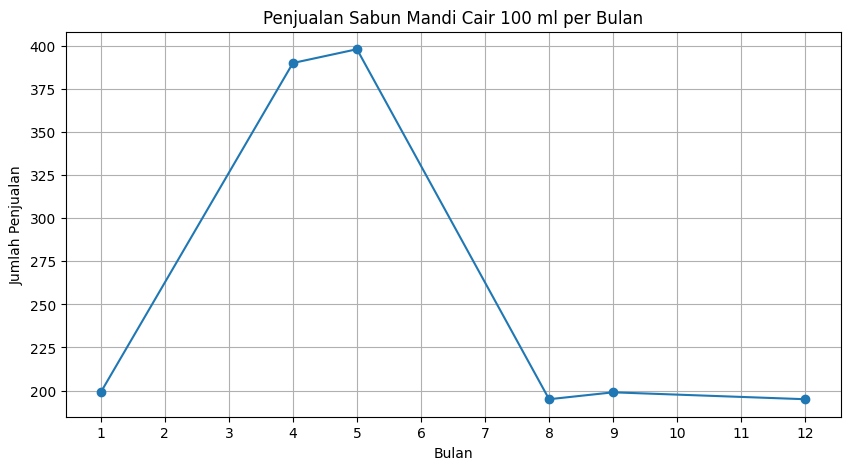

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    penjualan_bulanan.index,
    penjualan_bulanan.values,
    marker='o'
)

plt.title('Penjualan Sabun Mandi Cair 100 ml per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penjualan')
plt.grid(True)

plt.xticks(range(1,13))

plt.show()